## 1. 라이브러리 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

# 모델
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [ ]:
# %pip install lightgbm xgboost openpyxl

Note: you may need to restart the kernel to use updated packages.


## 2.데이터 불러오기

In [3]:
file_path = "E Commerce Dataset.xlsx"

df = pd.read_excel(file_path, sheet_name="E Comm")
print(df.shape)
print(df.head())
print(df.info())

(5630, 20)
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionScore MaritalSta

## 3.기본 점검 (결측치 확인)

In [4]:
# 결측치 개수
print(df.isnull().sum())

# 타깃 분포
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64
Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64


## 3-1. 결측치 타겟변수 관계 확인

In [ ]:
for col in ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder']:
    
    temp = df[col].isnull().astype(int)
    print(f"\n[{col} missing 여부별 Churn 평균]")
    print(df.groupby(temp)['Churn'].mean())


[Tenure missing 여부별 Churn 평균]
Tenure
0    0.161573
1    0.306818
Name: Churn, dtype: float64

[WarehouseToHome missing 여부별 Churn 평균]
WarehouseToHome
0    0.160625
1    0.334661
Name: Churn, dtype: float64

[HourSpendOnApp missing 여부별 Churn 평균]
HourSpendOnApp
0    0.165581
1    0.227451
Name: Churn, dtype: float64

[OrderAmountHikeFromlastYear missing 여부별 Churn 평균]
OrderAmountHikeFromlastYear
0    0.174091
1    0.052830
Name: Churn, dtype: float64

[CouponUsed missing 여부별 Churn 평균]
CouponUsed
0    0.174916
1    0.031250
Name: Churn, dtype: float64

[OrderCount missing 여부별 Churn 평균]
OrderCount
0    0.173120
1    0.069767
Name: Churn, dtype: float64

[DaySinceLastOrder missing 여부별 Churn 평균]
DaySinceLastOrder
0    0.167950
1    0.175896
Name: Churn, dtype: float64


## 3-2 결측 여부 indicator 변수 추가

In [6]:
# 결측 자체가 타겟과 관련 있을 가능성이 있으므로
# 원래 결측값은 그대로 두고, 결측 여부만 별도 변수로 추가한다.
missing_cols = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder'
]

for col in missing_cols:
    df[col + '_missing'] = df[col].isnull().astype(int)

print("\n결측 여부 변수 추가 후 컬럼 수:", len(df.columns))


결측 여부 변수 추가 후 컬럼 수: 27


## 4. X, y 분리

In [7]:
# CustomerID는 고객 식별용이라 예측에 쓰지 않는다.
# Churn은 타겟 변수다.
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

print("\n타겟 분포:")
print(y.value_counts())
print(y.value_counts(normalize=True))


타겟 분포:
Churn
0    4682
1     948
Name: count, dtype: int64
Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64


## 5.범주형 / 수치형 컬럼 구분

In [8]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("\n범주형 컬럼:")
print(categorical_cols)

print("\n수치형 컬럼:")
print(numeric_cols)



범주형 컬럼:
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

수치형 컬럼:
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Tenure_missing', 'WarehouseToHome_missing', 'HourSpendOnApp_missing', 'OrderAmountHikeFromlastYear_missing', 'CouponUsed_missing', 'OrderCount_missing', 'DaySinceLastOrder_missing']


C:\Users\Playdata\AppData\Local\Temp\ipykernel_18000\2763722455.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


## 6. 원-핫 인코딩

In [9]:
# LightGBM / XGBoost / CatBoost를 같은 입력 형태로 비교하기 위해
# 우선 pd.get_dummies()로 범주형 변수를 인코딩한다.
# drop_first=False로 두어 정보 손실을 줄인다.
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print("\n인코딩 후 데이터 크기:", X_encoded.shape)



인코딩 후 데이터 크기: (5630, 41)


# 7. 학습 / 테스트 데이터 분리

In [10]:
# stratify=y를 사용해 train/test에 이탈 비율이 비슷하게 유지되도록 한다.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n학습 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)



학습 데이터 크기: (4504, 41)
테스트 데이터 크기: (1126, 41)


# 8. 불균형 비율 계산

In [11]:
# 이탈 고객(1)이 상대적으로 적으므로
# 모델에 클래스 불균형 정보를 반영하기 위해 사용한다.
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("\n음성 클래스(0) 개수:", neg)
print("양성 클래스(1) 개수:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 4))


음성 클래스(0) 개수: 3746
양성 클래스(1) 개수: 758
scale_pos_weight: 4.942


# 9. 평가 함수 정의

In [12]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    모델 학습 후 주요 분류 성능 지표를 출력하는 함수
    """
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # 일부 모델은 predict_proba 지원
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    print("\n" + "=" * 60)
    print(f"[{model_name}]")
    print("=" * 60)

    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1-score :", round(f1_score(y_test, y_pred), 4))

    if y_prob is not None:
        print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

    print("\n[Classification Report]")
    print(classification_report(y_test, y_pred))

    print("[Confusion Matrix]")
    print(confusion_matrix(y_test, y_pred))

    # 결과 저장용 dict 반환
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }

    return result



# 10. LightGBM 모델

In [13]:
# LightGBM은 결측치를 자체 처리할 수 있다.
# n_estimators를 너무 크게 두지 않고 먼저 200 정도로 시작한다.
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42
)

# 11. XGBoost 모델

In [14]:
# XGBoost도 결측치를 자체 처리할 수 있다.
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

# 12. CatBoost 모델

In [16]:
# CatBoost도 결측치를 처리할 수 있다.
# 여기서는 get_dummies된 데이터를 그대로 넣는 비교 버전으로 작성한다.
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)


# 13. 모델 학습 및 평가

In [17]:
results = []

result_lgbm = evaluate_model(
    lgbm_model, X_train, X_test, y_train, y_test, "LightGBM"
)
results.append(result_lgbm)

result_xgb = evaluate_model(
    xgb_model, X_train, X_test, y_train, y_test, "XGBoost"
)
results.append(result_xgb)

result_cat = evaluate_model(
    cat_model, X_train, X_test, y_train, y_test, "CatBoost"
)
results.append(result_cat)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 758, number of negative: 3746
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000779 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 4504, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

[LightGBM]
Accuracy : 0.9689
Precision: 0.8638
Recall   : 0.9684
F1-score : 0.9132
ROC-AUC  : 0.9964

[Classification Report]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       936
           1       0.86      0.97      0.91       190

    accuracy                           0.97      1126
   macro avg       0.93 

# 14. 결과 비교표

In [18]:
result_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)

print("\n모델 비교표")
print(result_df)



모델 비교표
      Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  LightGBM  0.968917   0.863850  0.968421  0.913151  0.996441
1   XGBoost  0.950266   0.796460  0.947368  0.865385  0.986583
2  CatBoost  0.945826   0.910828  0.752632  0.824207  0.977075


# 15. 가장 좋은 모델 선택

In [19]:
best_model_name = result_df.iloc[0]['Model']
print("\n가장 성능이 좋은 모델:", best_model_name)


가장 성능이 좋은 모델: LightGBM


# 16. Feature Importance 확인

In [25]:
# 트리 기반 모델은 변수 중요도를 확인할 수 있다.
# 가장 좋은 모델에 따라 importance를 출력한다.
if best_model_name == "LightGBM":
    best_model = lgbm_model
elif best_model_name == "XGBoost":
    best_model = xgb_model
else:
    best_model = cat_model

importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\n상위 20개 중요 변수")
print(feature_importance_df.head(20))



상위 20개 중요 변수
                                feature  importance
2                       WarehouseToHome         689
0                                Tenure         650
12                       CashbackAmount         609
8           OrderAmountHikeFromlastYear         509
6                       NumberOfAddress         442
11                    DaySinceLastOrder         439
5                     SatisfactionScore         394
4              NumberOfDeviceRegistered         219
1                              CityTier         212
10                           OrderCount         209
7                              Complain         200
40                 MaritalStatus_Single         151
9                            CouponUsed         131
34  PreferedOrderCat_Laptop & Accessory         130
20        PreferredLoginDevice_Computer         130
3                        HourSpendOnApp         111
30                        Gender_Female          91
27      PreferredPaymentMode_Debit Card          8

# 17. 중요 변수 시각화

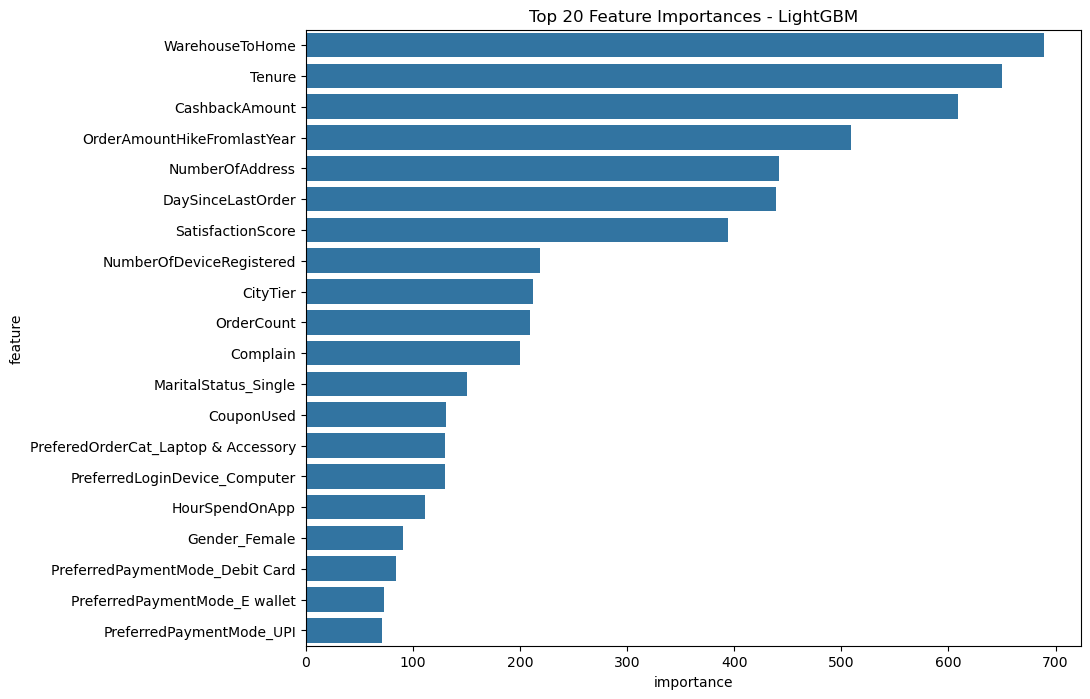

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df.head(20),
    x='importance',
    y='feature'
)
plt.title(f"Top 20 Feature Importances - {best_model_name}")
plt.show()